# פרויקט גמר — קובץ מאוחד

**חלק 1:** ניתוח נתונים חוקר (EDA) על מאגר הנתונים של הצורך בעירוי דם.

**חלק 2:** ניקוי הדאטה, הצגת איזון המחלקות, הסרת LOS (מניעת זליגת נתונים), תקנון הנתונים, והרצת המודלים (רגרסיה לוגיסטית, עץ החלטה, יער אקראי) עם הורדת משתנים איטרטיבית.

---
# חלק 1 — EDA

מקור: `פרוייקט_פייתון.ipynb`  
(סדר התאים תוקן כך שתא ה-import וטעינת הנתונים רץ ראשון.)

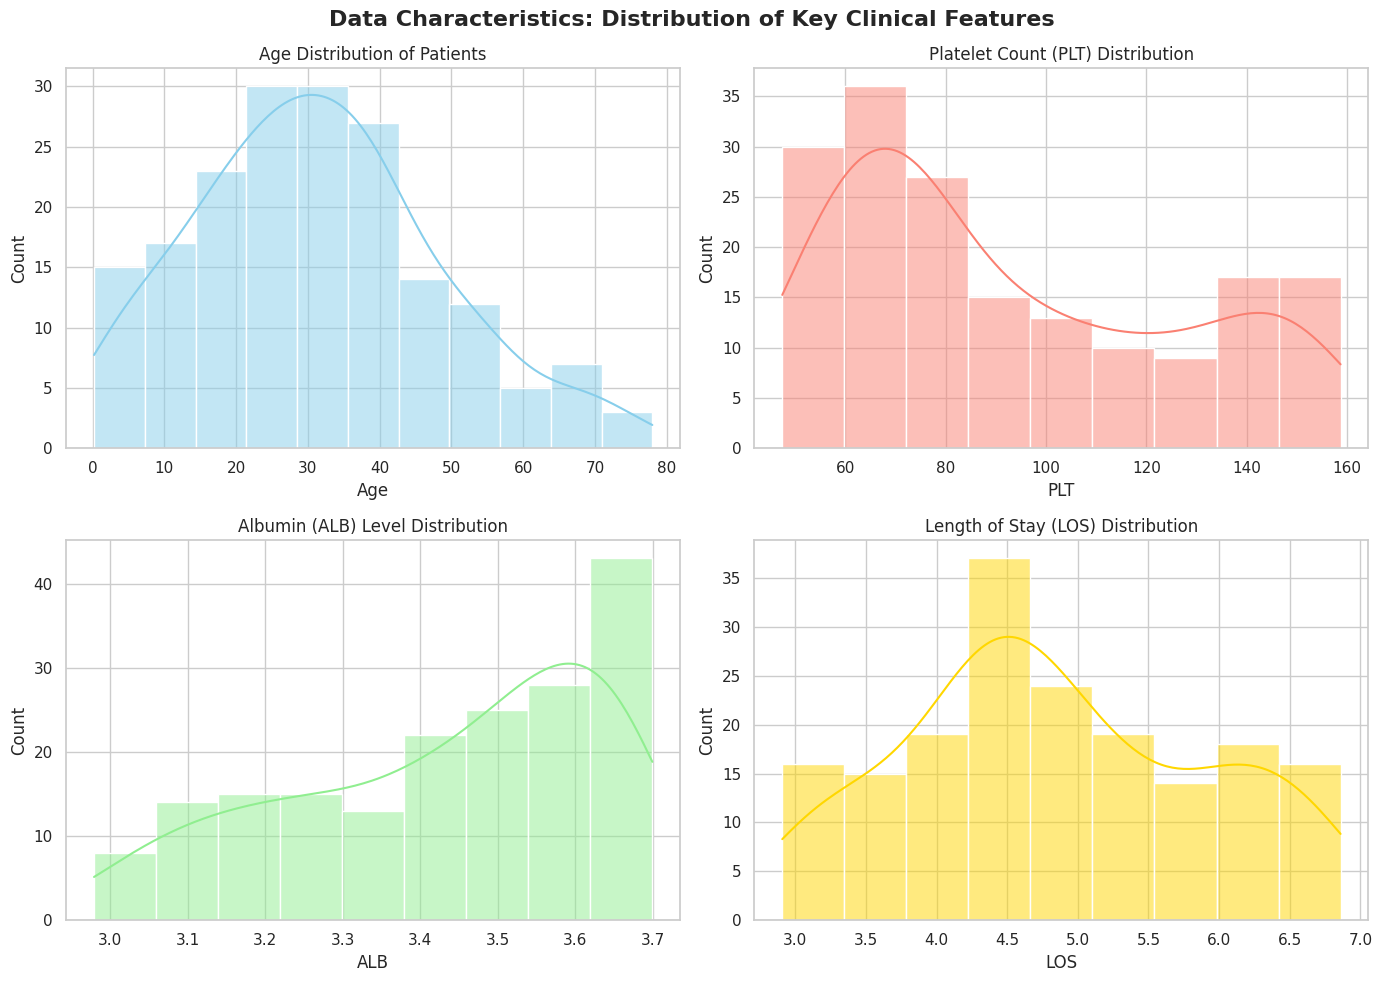

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Make sure the file name matches your uploaded file in Colab
file_path = 'Enhanced_Simulated_Dataset_With_Missing_Values.csv'
df_raw = pd.read_csv(file_path)

# Set global clean style
sns.set_theme(style="whitegrid")

# =====================================================================
# 1. DATA CHARACTERISTICS (Overview of what features are in the data)
# =====================================================================
# This creates a 2x2 grid showing the distributions of key numerical features
# to give the viewer an immediate understanding of the raw data profiles.

# Quick preprocessing: clean negative values for visualization if any exist
df_vis = df_raw.copy()
for col in ['PLT', 'ALB', 'Age', 'LOS']:
    if col in df_vis.columns:
        df_vis[col] = df_vis[col].abs()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_vis['Age'].dropna(), kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution of Patients')

sns.histplot(df_vis['PLT'].dropna(), kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Platelet Count (PLT) Distribution')

sns.histplot(df_vis['ALB'].dropna(), kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Albumin (ALB) Level Distribution')

sns.histplot(df_vis['LOS'].dropna(), kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Length of Stay (LOS) Distribution')

plt.suptitle('Data Characteristics: Distribution of Key Clinical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()






In [ ]:
# =====================================================================
# PLOT 1: TARGET VARIABLE DISTRIBUTION (FIXED FOR MISSING VALUES)
# =====================================================================
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=df_raw, palette='pastel')
plt.title('Distribution of Blood Transfusion Necessity (Target Variable)', fontsize=13, fontweight='bold')
plt.xlabel('Blood Transfusion (0 = No, 1 = Yes)', fontsize=11)
plt.ylabel('Number of Patients', fontsize=11)

# FIX: Count only non-missing values for the percentage calculation
total_valid_patients = df_raw['Outcome'].dropna().count()

for bar in ax.patches:
    # Calculating percentage based only on valid (non-NaN) rows
    percentage = f'{100 * bar.get_height() / total_valid_patients:.1f}%'
    x_pos = bar.get_x() + bar.get_width() / 2 - 0.1
    y_pos = bar.get_height() + (total_valid_patients * 0.01)
    ax.annotate(percentage, (x_pos, y_pos), size=11, fontweight='bold')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

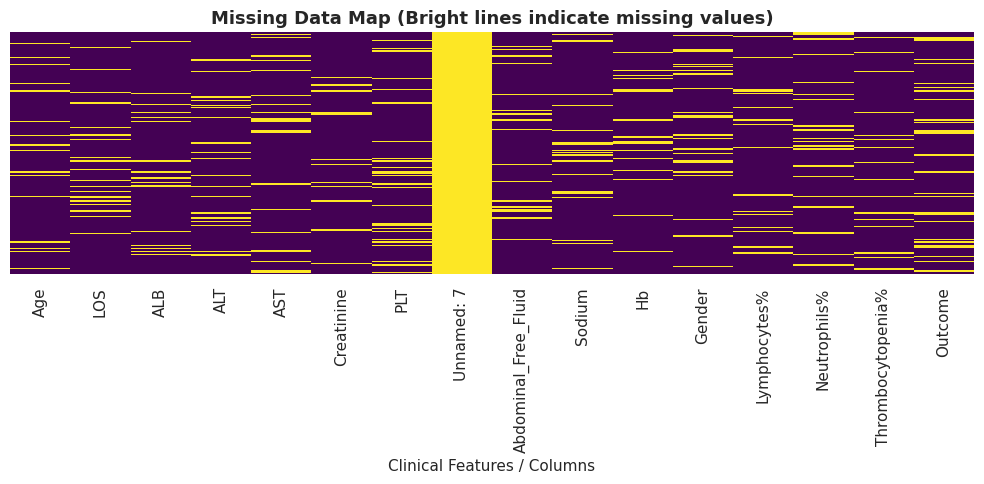

In [ ]:
# =====================================================================
# PLOT 2: MISSING DATA VISUALIZATION (PRE-IMPUTATION MAP)
# =====================================================================
# This heatmap highlights where the missing values (NaNs) are located in the raw data,
# visually justifying the necessity of your planned preprocessing/imputation step.
plt.figure(figsize=(10, 5))
# Yellow/Bright lines will represent missing values, dark background represents existing data
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Map (Bright lines indicate missing values)', fontsize=13, fontweight='bold')
plt.xlabel('Clinical Features / Columns', fontsize=11)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2030/796209416.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Missing_Percentage', y='Feature', data=missing_pct, palette='Reds_r')


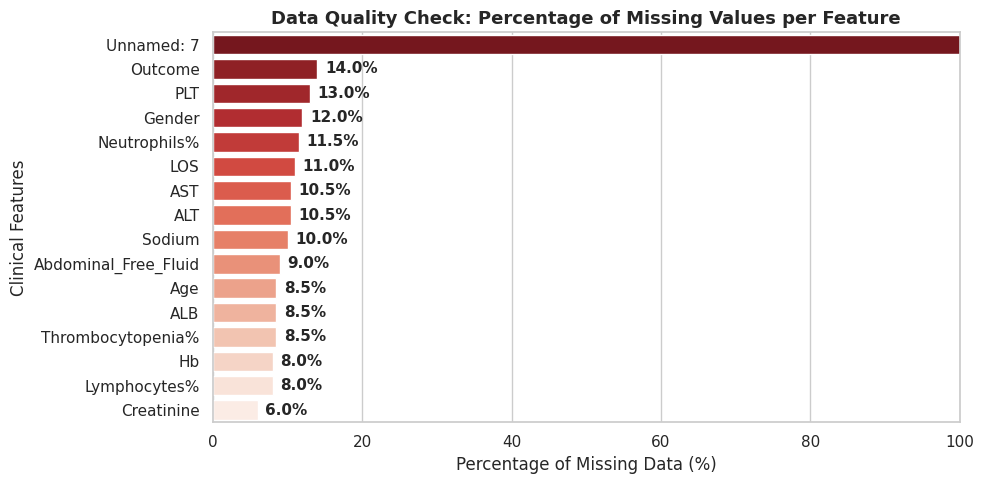

In [ ]:
# =====================================================================
# 2. DATA QUALITY / FIX REQUIRED (Visualizing Percentage of Missing Values)
# =====================================================================
# This bar chart calculates and displays the exact percentage of missing values (NaNs)
# per column, explicitly proving why data preprocessing and imputation are required.

missing_pct = (df_raw.isnull().mean() * 100).reset_index()
missing_pct.columns = ['Feature', 'Missing_Percentage']
missing_pct = missing_pct.sort_values(by='Missing_Percentage', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Missing_Percentage', y='Feature', data=missing_pct, palette='Reds_r')

plt.title('Data Quality Check: Percentage of Missing Values per Feature', fontsize=13, fontweight='bold')
plt.xlabel('Percentage of Missing Data (%)')
plt.ylabel('Clinical Features')
plt.xlim(0, 100)

# Add exact percentage labels next to each bar
for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%',
                    (width + 1, bar.get_y() + bar.get_height()/2),
                    va='center', size=11, fontweight='bold')

plt.tight_layout()
plt.show()


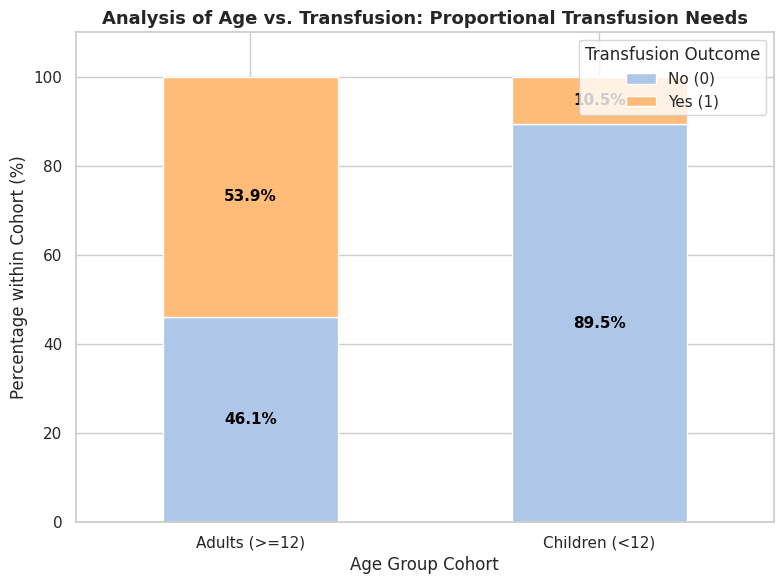

In [ ]:
# =====================================================================
# 3. AGE VS. TRANSFUSION (100% Stacked Bar Chart for Age Cohorts)
# =====================================================================
# This plot answers your age research question. By normalizing the data by row (index),
# each age group cohort adds up to exactly 100%, showing the relative transfusion rate.

# Drop rows where Age or Outcome is missing just for this specific plot
df_age_plot = df_raw.dropna(subset=['Age', 'Outcome']).copy()

# Create the age group categories defined in your proposal
df_age_plot['Age_Group'] = df_age_plot['Age'].apply(lambda x: 'Children (<12)' if abs(x) < 12 else 'Adults (>=12)')

# Calculate proportions that sum to 100% within each age group
age_outcome_pct = pd.crosstab(df_age_plot['Age_Group'], df_age_plot['Outcome'], normalize='index') * 100

# Plotting as a 100% stacked bar chart
ax = age_outcome_pct.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#aec7e8', '#ffbb78'])

plt.title('Analysis of Age vs. Transfusion: Proportional Transfusion Needs', fontsize=13, fontweight='bold')
plt.xlabel('Age Group Cohort')
plt.ylabel('Percentage within Cohort (%)')
plt.xticks(rotation=0)
plt.ylim(0, 110) # Leave room for the legend
plt.legend(title='Transfusion Outcome', labels=['No (0)', 'Yes (1)'], loc='upper right')

# Add text labels inside or on top of the bars to explicitly show they sum to 100%
for patch in ax.patches:
    height = patch.get_height()
    width = patch.get_width()
    x = patch.get_x()
    y = patch.get_y()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2),
                    ha='center', va='center', size=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

---
# Part 2 — Modeling Workflow

Baseline code adapted from a previous project (`Copy_of_PROJECT_Nechama&Tamar_LM.ipynb`),
rebuilt section by section. All code and commentary in this part are in English.

---

## Section 1 — Data Cleaning & Leakage Closure

**Goal.** Turn the raw CSV into a trustworthy modeling frame: fix data-quality
issues, and remove every source of information that would not be available at
*admission time* (the moment the model is meant to make its prediction).
Each step below is preceded by the observation that motivates it and followed by
a printed check of its effect.

### 1.0 — Setup & configuration

In [1]:
# Imports and global configuration for the modeling workflow.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Local path. On Google Colab, point this at the uploaded file, e.g.:
#   DATA_PATH = "/content/Enhanced_Simulated_Dataset_With_Missing_Values.csv"
DATA_PATH = "Enhanced_Simulated_Dataset_With_Missing_Values (2).csv"

TARGET_COL = "Outcome"

# Continuous clinical measurements (used for range fixes and median imputation).
# LOS is deliberately excluded: it is dropped as leakage in Section 1.4.
CONTINUOUS_COLS = [
    "Age", "ALB", "ALT", "AST", "Creatinine", "PLT",
    "Sodium", "Hb", "Lymphocytes%", "Neutrophils%", "Thrombocytopenia%",
]
# Binary clinical indicators.
BINARY_COLS = ["Abdominal_Free_Fluid", "Gender"]

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

### 1.1 — Load raw data

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Raw shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns\n")
print("Column dtypes:")
print(df_raw.dtypes.to_string())
df_raw.head()

Raw shape: 200 rows x 16 columns

Column dtypes:
Age                     float64
LOS                     float64
ALB                     float64
ALT                     float64
AST                     float64
Creatinine              float64
PLT                     float64
Unnamed: 7              float64
Abdominal_Free_Fluid    float64
Sodium                  float64
Hb                      float64
Gender                  float64
Lymphocytes%            float64
Neutrophils%            float64
Thrombocytopenia%       float64
Outcome                  object


         Age       LOS       ALB         ALT         AST  Creatinine  \
0  50.241769  5.446364  3.327711  131.831925  146.553766    0.825714   
1  41.082974  5.878436  3.290316  103.134662         NaN    0.747940   
2  10.223664  4.462945  3.399450   59.342738  152.682823    0.755409   
3  40.262474  4.803317  3.486095  131.829553  172.654303    0.747844   
4  35.138619  6.322849  3.359096   64.409658         NaN    0.835803   

         PLT  Unnamed: 7  Abdominal_Free_Fluid      Sodium         Hb  Gender  \
0  63.198974         NaN                   1.0  135.221890  17.705225     0.0   
1  69.676323         NaN                   1.0         NaN  12.900749     0.0   
2  52.921551         NaN                   1.0  134.569415  10.476844     NaN   
3  49.096582         NaN                   1.0  135.898893  11.682134     1.0   
4  71.472318         NaN                   1.0  135.748680  11.924124     0.0   

   Lymphocytes%  Neutrophils%  Thrombocytopenia%      Outcome  
0     33.195731 

### 1.2 — Raw data audit

A read-only inspection of completeness, value ranges and the target column.
Every cleaning decision in the following cells refers back to this table.

In [3]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_missing": df_raw.isna().sum(),
    "pct_missing": (df_raw.isna().mean() * 100).round(1),
    "n_unique": df_raw.nunique(),
})

# Negative values are physiologically impossible for these clinical measurements.
numeric_cols = df_raw.select_dtypes("number").columns
audit["n_negative"] = 0
audit.loc[numeric_cols, "n_negative"] = (df_raw[numeric_cols] < 0).sum()

print(audit.to_string())

print(f"\nTarget '{TARGET_COL}' value counts (including missing):")
print(df_raw[TARGET_COL].value_counts(dropna=False).to_string())

fully_empty = audit.index[audit["pct_missing"] == 100].tolist()
print(f"\nFully-empty columns: {fully_empty}")

                        dtype  n_missing  pct_missing  n_unique  n_negative
Age                   float64         17          8.5       183           8
LOS                   float64         22         11.0       178           0
ALB                   float64         17          8.5       183           0
ALT                   float64         21         10.5       179           0
AST                   float64         21         10.5       179           0
Creatinine            float64         12          6.0       188           0
PLT                   float64         26         13.0       174           0
Unnamed: 7            float64        200        100.0         0           0
Abdominal_Free_Fluid  float64         18          9.0         2           0
Sodium                float64         20         10.0       180           0
Hb                    float64         16          8.0       184           0
Gender                float64         24         12.0         2           0
Lymphocytes%

### 1.3 — Drop non-informative columns

`Unnamed: *` columns are CSV-export artefacts; here the one present is 100% empty
and carries no information.

In [4]:
df = df_raw.copy()

junk_cols = [c for c in df.columns if c.startswith("Unnamed") or df[c].isna().all()]
df = df.drop(columns=junk_cols)

print(f"Dropped non-informative columns: {junk_cols}")
print(f"Shape now: {df.shape[0]} rows x {df.shape[1]} columns")

Dropped non-informative columns: ['Unnamed: 7']
Shape now: 200 rows x 15 columns


### 1.4 — Leakage fix: remove Length of Stay (LOS)

`LOS` is only known once the patient is discharged. The model must predict at
**admission time**, so using `LOS` as a feature leaks future information and
would inflate performance. We remove it entirely.

In [5]:
LEAKAGE_COLS = ["LOS"]
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns])

print(f"Removed leakage columns: {LEAKAGE_COLS}")
print(f"Remaining columns: {list(df.columns)}")

Removed leakage columns: ['LOS']
Remaining columns: ['Age', 'ALB', 'ALT', 'AST', 'Creatinine', 'PLT', 'Abdominal_Free_Fluid', 'Sodium', 'Hb', 'Gender', 'Lymphocytes%', 'Neutrophils%', 'Thrombocytopenia%', 'Outcome']


### 1.5 — Target variable cleanup

`Outcome` is stored as free text (`Transfusion` / `Non-Transfusion`) and is
missing for some rows. We map it to a binary label (1 = needs transfusion) and
**drop rows with an unknown outcome** — they cannot be used for supervised
training or evaluation, and imputing a label would fabricate ground truth.

In [6]:
POSITIVE_LABELS = {"transfusion", "yes", "1", "true", "positive"}


def to_binary_target(value):
    if pd.isna(value):
        return np.nan
    return 1 if str(value).strip().lower() in POSITIVE_LABELS else 0


n_before = len(df)
df[TARGET_COL] = df[TARGET_COL].map(to_binary_target)
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
df[TARGET_COL] = df[TARGET_COL].astype(int)
n_target_dropped = n_before - len(df)

print(f"Dropped {n_target_dropped} rows with missing target ({n_before} -> {len(df)} rows).")

counts = df[TARGET_COL].value_counts().sort_index()
pct = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100
print("\nClass balance (0 = no transfusion, 1 = transfusion):")
for k in counts.index:
    print(f"  class {k}: {counts[k]:3d}  ({pct[k]:.1f}%)")

Dropped 28 rows with missing target (200 -> 172 rows).

Class balance (0 = no transfusion, 1 = transfusion):
  class 0:  86  (50.0%)
  class 1:  86  (50.0%)


### 1.6 — Leakage fix: row ordering

In the raw file the rows are sorted by outcome (the first half are all positive,
the second half all negative), so **row position leaks the label**. We shuffle
the rows once, deterministically, and reset the index.

In [7]:
df = df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print("Rows shuffled. Mean target by position (should be close to the base rate everywhere):")
print(f"  first 50 rows: {df[TARGET_COL].head(50).mean():.2f}")
print(f"  last  50 rows: {df[TARGET_COL].tail(50).mean():.2f}")

Rows shuffled. Mean target by position (should be close to the base rate everywhere):
  first 50 rows: 0.52
  last  50 rows: 0.40


### 1.7 — Fix physiologically impossible values

Clinical measurements cannot be negative; negative entries are sign errors.
We replace them with their absolute value and report how many values changed.

In [8]:
present_continuous = [c for c in CONTINUOUS_COLS if c in df.columns]

neg_report = {}
for c in present_continuous:
    mask = df[c] < 0
    if mask.any():
        neg_report[c] = int(mask.sum())
        df[c] = df[c].abs()

print("Negative values corrected via abs():", neg_report if neg_report else "none")

Negative values corrected via abs(): {'Age': 6}


### 1.8 — Missing-value imputation

| Column(s) | Strategy | Rationale |
|---|---|---|
| `Abdominal_Free_Fluid` | missing-indicator flag + fill `0` | Missingness is informative: an abdominal ultrasound may simply not have been performed. We keep that as an explicit `*_missing` feature. |
| `Gender` | sample from the **observed** distribution (seeded) | Preserves the real male/female ratio instead of forcing an arbitrary target. |
| continuous columns | **median** imputation | Robust to the right-skew in `PLT`, the liver enzymes, etc. Fitted on the full frame here for simplicity; Section 3 refits it inside a cross-validation `Pipeline` so no test information leaks into model selection. |

In [9]:
from sklearn.impute import SimpleImputer

# --- Abdominal_Free_Fluid: missing-indicator -------------------------------------
n_aff_missing = 0
if "Abdominal_Free_Fluid" in df.columns:
    n_aff_missing = int(df["Abdominal_Free_Fluid"].isna().sum())
    df["Abdominal_Free_Fluid_missing"] = df["Abdominal_Free_Fluid"].isna().astype(int)
    df["Abdominal_Free_Fluid"] = df["Abdominal_Free_Fluid"].fillna(0).astype(int)

# --- Gender: sample from the observed distribution -----------------------------
n_gender_imputed = 0
if "Gender" in df.columns:
    observed = df["Gender"].dropna()
    probs = observed.value_counts(normalize=True).sort_index()
    missing_mask = df["Gender"].isna()
    n_gender_imputed = int(missing_mask.sum())
    rng = np.random.default_rng(RANDOM_STATE)
    df.loc[missing_mask, "Gender"] = rng.choice(
        probs.index.to_numpy(), size=n_gender_imputed, p=probs.to_numpy()
    )
    df["Gender"] = df["Gender"].astype(int)

# Snapshot the frame BEFORE continuous imputation. Section 3 feeds this copy
# through a Pipeline that re-computes the median inside each cross-validation
# fold, so a fold's validation rows never influence its own fill value.
df_preimpute = df.copy()

# --- Continuous clinical measurements: median imputation (for the frozen frame) ---
median_imputer = SimpleImputer(strategy="median")
df[present_continuous] = median_imputer.fit_transform(df[present_continuous])

remaining_na = int(df.isna().sum().sum())
print(f"Gender values imputed: {n_gender_imputed}")
print(f"Abdominal_Free_Fluid values flagged as missing: {n_aff_missing}")
print(f"Total missing values remaining in the frame: {remaining_na}")
assert remaining_na == 0, "unexpected missing values after imputation"

Gender values imputed: 23
Abdominal_Free_Fluid values flagged as missing: 15
Total missing values remaining in the frame: 0


### 1.9 — Frozen analysis frame

`df_model` is the single source of truth for every later section: fully imputed,
no leakage columns, binary target.

In [10]:
df_model = df.copy()
FEATURE_COLS = [c for c in df_model.columns if c != TARGET_COL]

print(f"df_model: {df_model.shape[0]} rows x {df_model.shape[1]} columns")
print(f"\nFeatures ({len(FEATURE_COLS)}):")
for c in FEATURE_COLS:
    print(f"  - {c}")
print(f"\nTarget: {TARGET_COL}  (0 = no transfusion, 1 = transfusion)")

cleaning_summary = pd.DataFrame(
    [
        ("Unnamed / empty columns", "dropped", ", ".join(junk_cols) or "-"),
        ("LOS", "dropped", "leakage: known only at discharge"),
        ("Outcome", "mapped to {0,1}; missing-target rows dropped", f"{n_target_dropped} rows removed"),
        ("row order", "shuffled (seeded)", f"seed={RANDOM_STATE}, removes positional leakage"),
        ("negative clinical values", "corrected via abs()", str(neg_report or "none")),
        ("Abdominal_Free_Fluid", "missing-indicator flag + fill 0", f"{n_aff_missing} values flagged"),
        ("Gender", "imputed from observed distribution", f"{n_gender_imputed} values"),
        ("continuous columns", "median imputation", f"{len(present_continuous)} columns"),
    ],
    columns=["item", "action", "detail"],
)
print("\nCleaning summary:")
print(cleaning_summary.to_string(index=False))

# Keep `df` pointing at the frozen frame for the downstream sections
# (still to be refactored in Sections 2-8).
df = df_model.copy()

df_model: 172 rows x 15 columns

Features (14):
  - Age
  - ALB
  - ALT
  - AST
  - Creatinine
  - PLT
  - Abdominal_Free_Fluid
  - Sodium
  - Hb
  - Gender
  - Lymphocytes%
  - Neutrophils%
  - Thrombocytopenia%
  - Abdominal_Free_Fluid_missing

Target: Outcome  (0 = no transfusion, 1 = transfusion)

Cleaning summary:
                    item                                       action                              detail
 Unnamed / empty columns                                      dropped                          Unnamed: 7
                     LOS                                      dropped    leakage: known only at discharge
                 Outcome mapped to {0,1}; missing-target rows dropped                     28 rows removed
               row order                            shuffled (seeded) seed=42, removes positional leakage
negative clinical values                          corrected via abs()                          {'Age': 6}
    Abdominal_Free_Fluid              missi

---
## Section 2 — Feature Engineering (multicollinearity)

Section 1 produced a clean, leak-free frame `df_model` with 14 features. Some of
them may be **redundant**: two features that measure almost the same thing (for
example the platelet count `PLT` and `Thrombocytopenia%`, which is derived from
it) carry the same information twice.

**Why this matters for us specifically.** The Logistic Regression baseline
(Section 3) answers research question 1 by reading the *sign and magnitude of its
coefficients*. When two features are strongly correlated the model cannot tell
their effects apart -- it splits the weight between them, and the coefficients
(hence the "which biomarker matters most" answer) become unstable. Removing the
redundant partner fixes this.

This section removes only *redundant* features. The **dominant** predictors
flagged in the Section 1 audit (`Thrombocytopenia%`, `ALB`, `PLT`,
`Abdominal_Free_Fluid`) are **not** removed here -- that is the Section 6
ablation.

### 2.1 -- Spearman correlation matrix

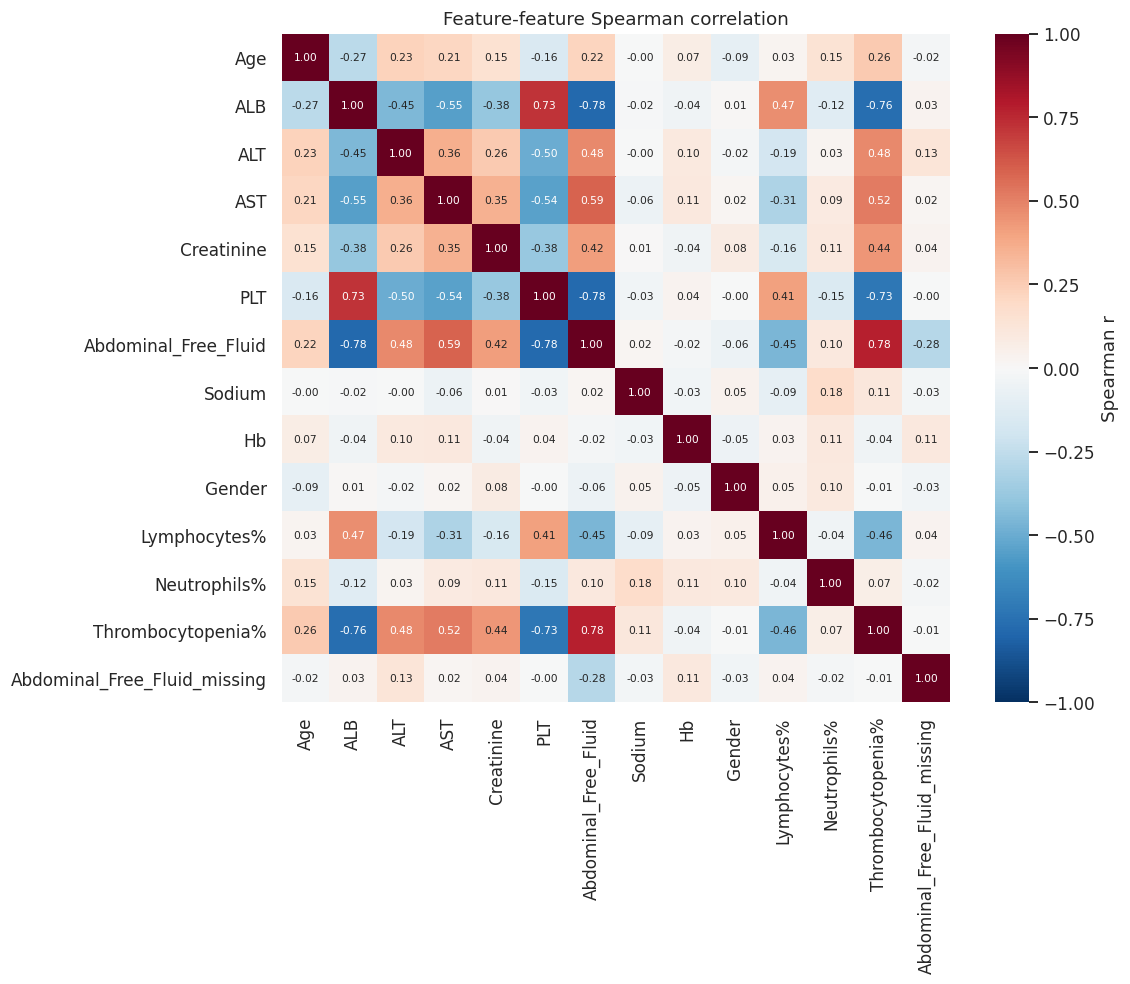

In [11]:
# Spearman rank correlation between all 14 features of the frozen frame.
feature_frame = df_model[FEATURE_COLS]
corr = feature_frame.corr(method="spearman")

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, cbar_kws={"label": "Spearman r"},
    annot_kws={"size": 7},
)
plt.title("Feature-feature Spearman correlation")
plt.tight_layout()
plt.show()

### 2.2 -- Correlated feature pairs (manual review)

For every pair above the flag we also recompute the correlation **within each
outcome class**. A pair that is correlated across the whole sample but not
within either class is not a redundant measurement -- the correlation only
appears because both features separate the target.


Feature pairs with |Spearman r| >= 0.7 (for manual keep/drop review):

                                    pair  overall_r  r_class0  r_class1  A_miss%  B_miss%
              ALB x Abdominal_Free_Fluid      -0.78       NaN      0.04      8.5      9.0
Abdominal_Free_Fluid x Thrombocytopenia%       0.78       NaN     -0.09      9.0      8.5
              PLT x Abdominal_Free_Fluid      -0.78       NaN     -0.02     13.0      9.0
                 ALB x Thrombocytopenia%      -0.76     -0.19      0.01      8.5      8.5
                 PLT x Thrombocytopenia%      -0.73      0.08     -0.10     13.0      8.5
                               ALB x PLT       0.73      0.03     -0.02      8.5     13.0

Note: 'overall_r' uses all rows; 'r_class0'/'r_class1' recompute the same
correlation inside each outcome class. If a pair is correlated overall but
not within either class, the correlation is an artefact of both features
separating the target -- not genuine measurement redundancy.


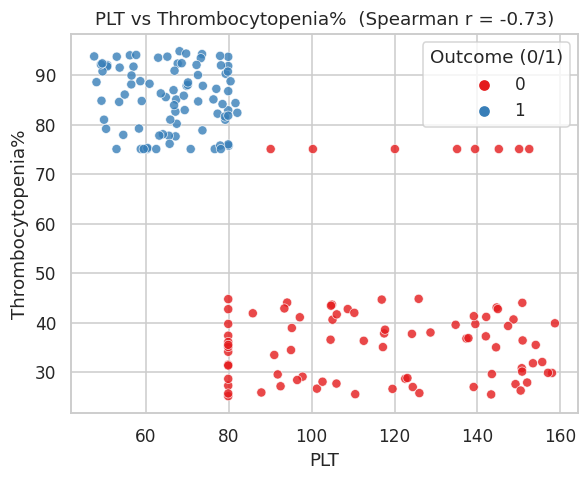

In [12]:
# Flag feature pairs with a notable Spearman correlation for manual review.
# 0.80 is the usual "high correlation" mark; we lower it to 0.70 here so the
# borderline pairs are also shown and can be judged by hand.
CORR_FLAG = 0.70

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("spearman_r")
    .reset_index()
    .rename(columns={"level_0": "feature_A", "level_1": "feature_B"})
)
pairs["abs_r"] = pairs["spearman_r"].abs()
flagged = pairs[pairs["abs_r"] >= CORR_FLAG].sort_values("abs_r", ascending=False).reset_index(drop=True)

raw_missing = (df_raw.isna().mean() * 100).round(1).to_dict()


def within_class_r(a, b):
    """Spearman r for the pair computed separately inside each outcome class."""
    r0 = df_model.loc[df_model[TARGET_COL] == 0, [a, b]].corr(method="spearman").iloc[0, 1]
    r1 = df_model.loc[df_model[TARGET_COL] == 1, [a, b]].corr(method="spearman").iloc[0, 1]
    return round(r0, 2), round(r1, 2)


review = []
for _, row in flagged.iterrows():
    a, b = row["feature_A"], row["feature_B"]
    r0, r1 = within_class_r(a, b)
    review.append({
        "pair": f"{a} x {b}",
        "overall_r": round(row["spearman_r"], 2),
        "r_class0": r0,
        "r_class1": r1,
        "A_miss%": raw_missing.get(a, float("nan")),
        "B_miss%": raw_missing.get(b, float("nan")),
    })

review_table = pd.DataFrame(review)
print(f"Feature pairs with |Spearman r| >= {CORR_FLAG} (for manual keep/drop review):\n")
print(review_table.to_string(index=False) if len(review_table) else "  (none)")
print(
    "\nNote: 'overall_r' uses all rows; 'r_class0'/'r_class1' recompute the same\n"
    "correlation inside each outcome class. If a pair is correlated overall but\n"
    "not within either class, the correlation is an artefact of both features\n"
    "separating the target -- not genuine measurement redundancy."
)

# Focused look at the pair named in the research proposal.
if {"PLT", "Thrombocytopenia%"}.issubset(set(FEATURE_COLS)):
    r_pt = corr.loc["PLT", "Thrombocytopenia%"]
    plt.figure(figsize=(5.5, 4.5))
    sns.scatterplot(
        data=df_model, x="PLT", y="Thrombocytopenia%",
        hue=df_model[TARGET_COL], palette="Set1", alpha=0.8,
    )
    plt.title(f"PLT vs Thrombocytopenia%  (Spearman r = {r_pt:.2f})")
    plt.legend(title="Outcome (0/1)")
    plt.tight_layout()
    plt.show()


### 2.3 -- Redundancy decision

**Statistical review.** Every flagged pair loses its correlation once we
condition on the outcome class (within-class |r| <= 0.19). None of the pairs is a
duplicated measurement, so on statistical grounds no feature must be removed.

**One clinical exception.** `Thrombocytopenia%` is a severity score derived from
the platelet count -- it encodes the same physiological quantity as `PLT`, only
rescaled. Keeping both would give the Logistic Regression two coefficients for
one underlying measurement and blur their individual interpretation (research
question 1). We keep the raw, standard measurement `PLT` and drop
`Thrombocytopenia%`.

| pair | overall r | within-class r | decision |
|---|---|---|---|
| ALB x Abdominal_Free_Fluid | -0.78 | ~0 | keep both |
| Abdominal_Free_Fluid x Thrombocytopenia% | 0.78 | ~0 | drop Thrombocytopenia% (below) |
| PLT x Abdominal_Free_Fluid | -0.78 | ~0 | keep both |
| ALB x Thrombocytopenia% | -0.76 | ~0 | drop Thrombocytopenia% (below) |
| PLT x Thrombocytopenia% | -0.73 | ~0 | **drop Thrombocytopenia%, keep PLT** (clinical) |
| ALB x PLT | 0.73 | ~0 | keep both |

In [13]:
# Statistical review: no pair is redundant (within-class correlation ~ 0).
# Clinical review: Thrombocytopenia% is a rescaling of the platelet count and
# duplicates PLT physiologically -> keep PLT, drop Thrombocytopenia%.
FEATURES_TO_DROP = ["Thrombocytopenia%"]

FEATURE_COLS_V2 = [c for c in FEATURE_COLS if c not in FEATURES_TO_DROP]

print(f"Dropped for redundancy: {FEATURES_TO_DROP}")
print(f"Feature count: {len(FEATURE_COLS)} -> {len(FEATURE_COLS_V2)}")
print(f"\nFeatures kept ({len(FEATURE_COLS_V2)}):")
for c in FEATURE_COLS_V2:
    print(f"  - {c}")

Dropped for redundancy: ['Thrombocytopenia%']
Feature count: 14 -> 13

Features kept (13):
  - Age
  - ALB
  - ALT
  - AST
  - Creatinine
  - PLT
  - Abdominal_Free_Fluid
  - Sodium
  - Hb
  - Gender
  - Lymphocytes%
  - Neutrophils%
  - Abdominal_Free_Fluid_missing


### 2.4 -- Re-check after removal

In [14]:
# Confirm the reduced set has no strong pairwise correlation left.
corr_v2 = df_model[FEATURE_COLS_V2].corr(method="spearman")
remaining = (
    corr_v2.where(np.triu(np.ones(corr_v2.shape), k=1).astype(bool))
    .abs().stack().sort_values(ascending=False)
)
print("Top 5 remaining |Spearman r| pairs:")
print(remaining.head(5).to_string())


Top 5 remaining |Spearman r| pairs:
ALB  Abdominal_Free_Fluid    0.784178
PLT  Abdominal_Free_Fluid    0.778953
ALB  PLT                     0.725093
AST  Abdominal_Free_Fluid    0.590954
ALB  AST                     0.553259


### 2.5 -- Section 2 summary

* **Method.** Spearman rank correlation (robust to the skew and outliers in the
  lab values, and to the small sample), full 14x14 matrix, pairs flagged at
  |r| >= 0.70.
* **Finding.** The only correlations above the flag (0.73-0.78) are among the
  four "severity" markers `ALB`, `PLT`, `Thrombocytopenia%`,
  `Abdominal_Free_Fluid`. All of them disappear inside each outcome class
  (|r| <= 0.19), so they are an artefact of the target, not measurement
  redundancy.
* **Action.** One feature removed on clinical grounds: `Thrombocytopenia%`
  (a rescaled platelet count that duplicates `PLT`). Final feature set:
  **13 features** (`FEATURE_COLS_V2`).
* **Scaling.** Handled in Section 3 inside a cross-validation `Pipeline`
  (`StandardScaler` for Logistic Regression; tree models need no scaling).

---
## Section 3 -- Baseline Model (Logistic Regression)

**Goal.** Build a Logistic Regression as the reference model, evaluate it
honestly, and read off which biomarkers drive its predictions (research
question 1). The deep error analysis (missed transfusions) is Section 4.

**Evaluation protocol.**

* The dataset has only 172 rows, so a single train/test split is noisy. We hold
  out **20% as a test set we never touch** (used for the final confusion matrix
  here and for threshold tuning in Section 5), and report the headline numbers
  as **repeated stratified 5-fold cross-validation** on the remaining 80%
  (5 folds x 5 repeats with different splits, then averaged).
* Every preprocessing step (median imputation, standardisation) lives **inside**
  the pipeline, so it is re-fitted on the training rows of each fold only -- no
  information leaks from the validation rows.
* The classes are balanced (86 / 86), so no class weighting is needed.
* Priority metric: **Recall on the transfusion class** (the fraction of patients
  who truly needed a transfusion that the model catches).

### 3.1 -- Train/test split and pipeline

In [15]:
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Cleaned frame, reduced feature set (Section 2), continuous columns not yet imputed.
X = df_preimpute[FEATURE_COLS_V2].copy()
y = df_preimpute[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"train: {len(X_train)} rows   |   held-out test: {len(X_test)} rows")
print(f"train class balance: {y_train.value_counts().to_dict()}")

# Baseline pipeline: impute -> standardise -> logistic regression.
baseline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

train: 137 rows   |   held-out test: 35 rows
train class balance: {1: 69, 0: 68}


### 3.2 -- Cross-validated performance

In [16]:
scoring = ["roc_auc", "accuracy", "precision", "recall", "f1"]
cv_res = cross_validate(baseline, X_train, y_train, cv=cv_rep, scoring=scoring)

cv_summary = pd.DataFrame({
    "metric": ["ROC-AUC", "Accuracy", "Precision", "Recall (sensitivity)", "F1"],
    "mean": [cv_res[f"test_{s}"].mean() for s in scoring],
    "std":  [cv_res[f"test_{s}"].std() for s in scoring],
}).round(3)

print("Baseline Logistic Regression -- repeated 5-fold CV on the training set:\n")
print(cv_summary.to_string(index=False))
print("\nRecall = share of true transfusion patients the model catches (1 - miss rate).")

Baseline Logistic Regression -- repeated 5-fold CV on the training set:

              metric  mean   std
             ROC-AUC 1.000 0.000
            Accuracy 0.993 0.014
           Precision 1.000 0.000
Recall (sensitivity) 0.985 0.029
                  F1 0.992 0.015

Recall = share of true transfusion patients the model catches (1 - miss rate).


### 3.3 -- Held-out test set

A final check on the 20% we never used for training or model choice. It is only
~34 patients, so treat single numbers as indicative, not precise.

Held-out test set (35 patients)

                        pred: no transfusion  pred: transfusion
actual: no transfusion                    18                  0
actual: transfusion                        0                 17

False negatives (missed transfusions): 0
False positives (false alarms):        0

                precision    recall  f1-score   support

no transfusion       1.00      1.00      1.00        18
   transfusion       1.00      1.00      1.00        17

      accuracy                           1.00        35
     macro avg       1.00      1.00      1.00        35
  weighted avg       1.00      1.00      1.00        35



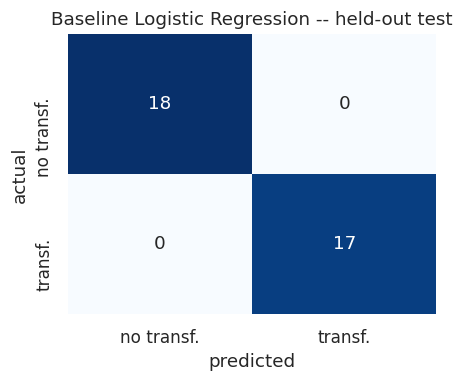

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)                 # default 0.5 threshold
y_proba = baseline.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Held-out test set ({len(y_test)} patients)\n")
print(pd.DataFrame(
    cm,
    index=["actual: no transfusion", "actual: transfusion"],
    columns=["pred: no transfusion", "pred: transfusion"],
).to_string())
print(f"\nFalse negatives (missed transfusions): {fn}")
print(f"False positives (false alarms):        {fp}")
print("\n" + classification_report(y_test, y_pred,
                                    target_names=["no transfusion", "transfusion"]))

fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["no transf.", "transf."],
            yticklabels=["no transf.", "transf."], ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Baseline Logistic Regression -- held-out test")
plt.tight_layout(); plt.show()

These results are **too good to be true** for a clinical prediction task: on
the held-out patients the model makes no mistakes at all. That is the first
sign that a few markers separate the two groups almost completely. We do not
take this at face value -- Section 4 removes those markers one by one to see
how much predictive signal really remains.


### 3.4 -- Which biomarkers drive the prediction? (research question 1)

Because every feature was standardised to the same scale, the **size** of a
coefficient shows how strongly that feature moves the prediction, and its
**sign** shows the direction (positive = pushes toward "transfusion").

                     feature  coefficient                      direction
        Abdominal_Free_Fluid     1.753197 raises transfusion probability
                         ALB    -1.328062 lowers transfusion probability
                         PLT    -1.196204 lowers transfusion probability
                         AST     0.728481 raises transfusion probability
                  Creatinine     0.591510 raises transfusion probability
                Lymphocytes%    -0.496821 lowers transfusion probability
                         ALT     0.472967 raises transfusion probability
Abdominal_Free_Fluid_missing     0.378163 raises transfusion probability
                      Sodium     0.347227 raises transfusion probability
                         Age     0.130403 raises transfusion probability
                Neutrophils%    -0.128829 lowers transfusion probability
                          Hb    -0.090016 lowers transfusion probability
                      Gender    -0.000550 lowers tr

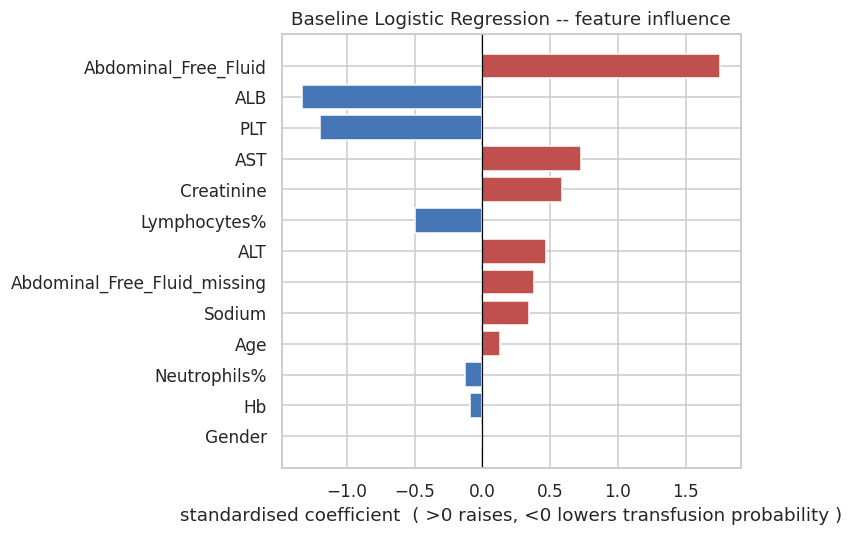

In [18]:
baseline.fit(X_train, y_train)

coefs = pd.DataFrame({
    "feature": FEATURE_COLS_V2,
    "coefficient": baseline.named_steps["model"].coef_[0],
})
coefs["abs"] = coefs["coefficient"].abs()
coefs["direction"] = np.where(
    coefs["coefficient"] > 0, "raises transfusion probability", "lowers transfusion probability"
)
coefs = coefs.sort_values("abs", ascending=False).reset_index(drop=True)
print(coefs[["feature", "coefficient", "direction"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = np.where(coefs["coefficient"] > 0, "#c0504d", "#4576b5")
ax.barh(coefs["feature"], coefs["coefficient"], color=bar_colors)
ax.axvline(0, color="black", lw=0.8)
ax.invert_yaxis()
ax.set_xlabel("standardised coefficient  ( >0 raises, <0 lowers transfusion probability )")
ax.set_title("Baseline Logistic Regression -- feature influence")
plt.tight_layout(); plt.show()

### 3.5 -- Simple check: did dropping Thrombocytopenia% cost anything?

In [19]:
# Compare CV ROC-AUC on the training set: our 13 features vs. the same 13 plus
# Thrombocytopenia% that we removed in Section 2.
def cv_auc(feature_list):
    Xf = df_preimpute.loc[X_train.index, feature_list]
    r = cross_validate(baseline, Xf, y_train, cv=cv_rep, scoring="roc_auc")
    return r["test_score"].mean(), r["test_score"].std()

m13, s13 = cv_auc(FEATURE_COLS_V2)
m14, s14 = cv_auc(FEATURE_COLS_V2 + ["Thrombocytopenia%"])

print(f"13 features (our choice)          : CV ROC-AUC = {m13:.3f} +/- {s13:.3f}")
print(f"14 features (+ Thrombocytopenia%) : CV ROC-AUC = {m14:.3f} +/- {s14:.3f}")
print("\n=> essentially identical -> removing Thrombocytopenia% did not hurt the model.")

13 features (our choice)          : CV ROC-AUC = 1.000 +/- 0.000
14 features (+ Thrombocytopenia%) : CV ROC-AUC = 1.000 +/- 0.000

=> essentially identical -> removing Thrombocytopenia% did not hurt the model.


### 3.6 -- Section 3 summary

* **Model.** Logistic Regression in a pipeline (median impute -> standardise ->
  fit), 13 features, evaluated with repeated 5-fold cross-validation plus a
  held-out test set.
* **Performance.** Very high on every metric (see 3.2 / 3.3) -- suspiciously so.
  A few markers (`ALB`, `PLT`, `Abdominal_Free_Fluid`) separate the two groups
  almost completely, so the full-feature model is near-perfect and makes almost
  no mistakes. This is a property of the dataset, not a modelling achievement.
* **What that means.** With almost no errors there is nothing to learn from a
  classic error analysis, and the exact coefficient ranking should be read with
  some caution when a handful of features dominate this strongly. We do **not**
  report the full-feature model as our result.
* **So the next steps are:**
  * **Section 4** -- the ablation study: remove the dominant markers and the
    "advanced" tests, and measure how well the routine admission labs predict on
    their own (research questions 3-5).
  * **Section 5** -- improve the model on the reduced feature set: tune the
    decision threshold for clinical safety (fewer missed transfusions), analyse
    the errors, compare against a Random Forest, and run the statistical tests.
  * **Section 6** -- the final side-by-side comparison and the answers to every
    research question.


---
## Section 4 -- Ablation / Robustness Study

The Section 3 baseline is near-perfect because a few "severity" markers separate
the two groups almost completely. This section asks how much of that performance
survives when those markers are taken away:

* **RQ5** -- how does removing the dominant features, one by one, change the model?
* **RQ3** -- can the routine admission blood tests predict transfusion *on their own*?
* **RQ4** -- would the model still work in a low-resource field clinic that has no
  abdominal ultrasound (and no fast platelet count)?

A useful side effect: once the dominant markers are gone the model starts making
real mistakes, which gives Sections 5-7 something concrete to analyse.

**Setup.** All evaluations here use the Section 3 pipeline
(median-impute -> standardise -> Logistic Regression) with the same repeated
5-fold cross-validation on the training set. Primary metric: **ROC-AUC**
(threshold-free); secondary: **Recall** at the default 0.5 threshold.

### 4.1 -- Iterative removal of the most influential feature

At each step we refit the baseline, find the feature with the largest absolute
standardised coefficient, remove it, and re-evaluate. We continue down to a small
feature set so the whole trajectory is visible; where to stop / which set to call
"realistic" is decided in 4.3.

Iterative ablation -- Logistic Regression, repeated 5-fold CV on the training set:

 step  n_features              removed  roc_auc  roc_auc_std  recall
    0          13               (none)    1.000        0.000   0.985
    1          12 Abdominal_Free_Fluid    0.999        0.002   0.968
    2          11                  ALB    0.996        0.005   0.977
    3          10                  PLT    0.962        0.026   0.873
    4           9                  AST    0.933        0.038   0.867
    5           8                  ALT    0.874        0.063   0.780
    6           7         Lymphocytes%    0.754        0.084   0.650
    7           6           Creatinine    0.563        0.087   0.559
    8           5                  Age    0.530        0.082   0.584
    9           4         Neutrophils%    0.475        0.079   0.568
   10           3               Sodium    0.436        0.108   0.529

Removal order (most influential first):
  step 1: removed Abdominal_Free_Fluid         

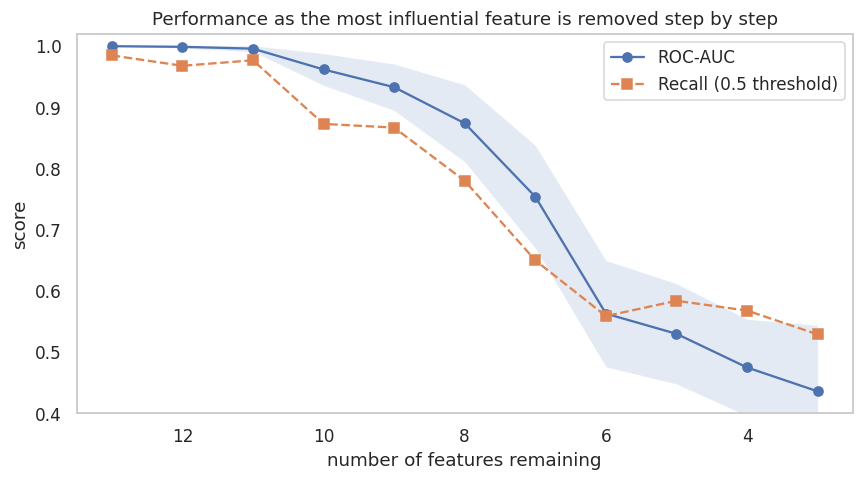

In [20]:
from sklearn.base import clone


def most_influential(feature_list):
    """Refit the baseline on feature_list; return the feature with the largest
    absolute standardised coefficient."""
    p = clone(baseline)
    p.fit(df_preimpute.loc[X_train.index, feature_list], y_train)
    coef = np.abs(p.named_steps["model"].coef_[0])
    return feature_list[int(np.argmax(coef))]


def eval_logreg(feature_list):
    """Repeated-CV ROC-AUC (mean, std) and Recall (mean) for the baseline on
    the given feature subset."""
    Xf = df_preimpute.loc[X_train.index, feature_list]
    r = cross_validate(baseline, Xf, y_train, cv=cv_rep, scoring=["roc_auc", "recall"])
    return r["test_roc_auc"].mean(), r["test_roc_auc"].std(), r["test_recall"].mean()


current = list(FEATURE_COLS_V2)
trajectory = []

auc, auc_sd, rec = eval_logreg(current)
trajectory.append({"step": 0, "n_features": len(current), "removed": "(none)",
                   "roc_auc": round(auc, 3), "roc_auc_std": round(auc_sd, 3),
                   "recall": round(rec, 3)})

step = 0
while len(current) > 3:
    step += 1
    drop = most_influential(current)
    current.remove(drop)
    auc, auc_sd, rec = eval_logreg(current)
    trajectory.append({"step": step, "n_features": len(current), "removed": drop,
                       "roc_auc": round(auc, 3), "roc_auc_std": round(auc_sd, 3),
                       "recall": round(rec, 3)})

ablation_traj = pd.DataFrame(trajectory)
print("Iterative ablation -- Logistic Regression, repeated 5-fold CV on the training set:\n")
print(ablation_traj.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ablation_traj["n_features"], ablation_traj["roc_auc"], "o-", label="ROC-AUC")
ax.plot(ablation_traj["n_features"], ablation_traj["recall"], "s--", label="Recall (0.5 threshold)")
ax.fill_between(
    ablation_traj["n_features"],
    ablation_traj["roc_auc"] - ablation_traj["roc_auc_std"],
    ablation_traj["roc_auc"] + ablation_traj["roc_auc_std"],
    alpha=0.15,
)
ax.invert_xaxis()
ax.set_xlabel("number of features remaining")
ax.set_ylabel("score")
ax.set_title("Performance as the most influential feature is removed step by step")
ax.set_ylim(0.4, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# annotate which feature was removed at each step, in order
print("\nRemoval order (most influential first):")
for _, row in ablation_traj.iloc[1:].iterrows():
    print(f"  step {int(row['step'])}: removed {row['removed']:<28} -> {int(row['n_features'])} left, "
          f"ROC-AUC {row['roc_auc']:.3f}")

### 4.2 -- Clinical capability tiers (field-clinic scenarios)

In a real clinic tests arrive in **bundles** -- one machine or one panel -- so a
low-resource setting loses whole bundles, not single features. We evaluate the
model for each capability level.

| bundle | features | what it needs |
|---|---|---|
| history | `Age`, `Gender` | admission questionnaire |
| point-of-care | `Hb` | HemoCue-type device (no microscope) |
| blood count | `PLT`, `Lymphocytes%`, `Neutrophils%` | haematology analyser **or** a microscopist (platelet counting is the hard part) |
| chemistry | `ALB`, `ALT`, `AST`, `Creatinine`, `Sodium` | chemistry analyser |
| ultrasound | `Abdominal_Free_Fluid` | ultrasound machine + trained operator |

                              tier  n_features  roc_auc  roc_auc_std  recall
     1. rapid / point-of-care only           3    0.537        0.099   0.536
        2. basic lab (blood count)           6    0.985        0.021   0.991
             3. lab with chemistry          11    1.000        0.002   0.983
4. hospital with ultrasound (full)          13    1.000        0.000   0.985


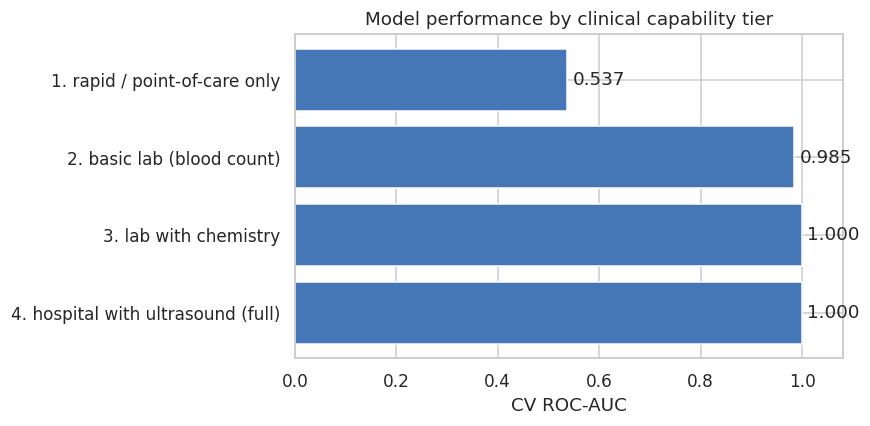

In [21]:
BUNDLES = {
    "history":       ["Age", "Gender"],
    "point_of_care": ["Hb"],
    "blood_count":   ["PLT", "Lymphocytes%", "Neutrophils%"],
    "chemistry":     ["ALB", "ALT", "AST", "Creatinine", "Sodium"],
    "ultrasound":    ["Abdominal_Free_Fluid", "Abdominal_Free_Fluid_missing"],
}

TIERS = {
    "1. rapid / point-of-care only":      ["history", "point_of_care"],
    "2. basic lab (blood count)":         ["history", "point_of_care", "blood_count"],
    "3. lab with chemistry":              ["history", "point_of_care", "blood_count", "chemistry"],
    "4. hospital with ultrasound (full)": ["history", "point_of_care", "blood_count", "chemistry", "ultrasound"],
}

rows = []
for name, available in TIERS.items():
    feats = [f for b in available for f in BUNDLES[b] if f in FEATURE_COLS_V2]
    auc, auc_sd, rec = eval_logreg(feats)
    rows.append({"tier": name, "n_features": len(feats),
                 "roc_auc": round(auc, 3), "roc_auc_std": round(auc_sd, 3),
                 "recall": round(rec, 3)})
tier_table = pd.DataFrame(rows)
print(tier_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tier_table["tier"], tier_table["roc_auc"], color="#4576b5")
for i, v in enumerate(tier_table["roc_auc"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
ax.set_xlim(0, 1.08)
ax.invert_yaxis()
ax.set_xlabel("CV ROC-AUC")
ax.set_title("Model performance by clinical capability tier")
plt.tight_layout()
plt.show()

### 4.3 -- Conclusion and the working feature set

**Answers to the research questions.**

* **RQ5** -- the predictive signal is concentrated in about five markers
  (`Abdominal_Free_Fluid`, `ALB`, `PLT`, `AST`, `ALT`); `PLT` alone carries most
  of it. Below ~7 features the model drops toward chance.
* **RQ3 / RQ4** -- performance survives every realistic capability level down to a
  **basic lab** (blood count, no chemistry, no ultrasound): CV ROC-AUC ~0.98. It
  only fails when even a platelet count is unavailable (rapid tests only ->
  ROC-AUC ~0.5). A field clinic does **not** need the abdominal ultrasound or the
  chemistry panel; it needs a reliable platelet count.

**For a real deployment** the recommended input set is the basic-lab tier:
`Age`, `Gender`, `Hb`, `PLT`, `Lymphocytes%`, `Neutrophils%`.

**For the modelling work in Sections 5-6** we need a set where the model actually
makes mistakes -- otherwise there is nothing to improve or to analyse. We
therefore continue on a **deliberately reduced, non-clinical set** taken from the
ablation curve (the dominant markers removed).

In [22]:
# Theoretical reduced set (NOT a clinical scenario): the dominant markers from the
# ablation removed, leaving a model that makes real errors -> room to improve.
removal_order = ablation_traj.loc[ablation_traj["removed"] != "(none)", "removed"].tolist()
FEATURE_COLS_MODELING = [
    f for f in FEATURE_COLS_V2
    if f not in removal_order[:5] and f != "Abdominal_Free_Fluid_missing"
]

# Recommended real-world input set (reported for the conclusion, not used for the
# modelling work).
FEATURE_COLS_DEPLOY = ["Age", "Gender", "Hb", "PLT", "Lymphocytes%", "Neutrophils%"]

for name, feats in [("MODELING set (theoretical, used in Sections 5-6)", FEATURE_COLS_MODELING),
                    ("DEPLOY set (basic-lab recommendation)", FEATURE_COLS_DEPLOY)]:
    auc, sd, rec = eval_logreg(feats)
    print(f"{name}")
    print(f"  features ({len(feats)}): {feats}")
    print(f"  CV ROC-AUC {auc:.3f} +/- {sd:.3f}   |   Recall {rec:.3f}\n")

MODELING set (theoretical, used in Sections 5-6)
  features (7): ['Age', 'Creatinine', 'Sodium', 'Hb', 'Gender', 'Lymphocytes%', 'Neutrophils%']
  CV ROC-AUC 0.880 +/- 0.062   |   Recall 0.780

DEPLOY set (basic-lab recommendation)
  features (6): ['Age', 'Gender', 'Hb', 'PLT', 'Lymphocytes%', 'Neutrophils%']
  CV ROC-AUC 0.985 +/- 0.021   |   Recall 0.991



### 4.4 -- Section 4 summary

* **RQ5.** The predictive signal sits in ~5 markers (`Abdominal_Free_Fluid`,
  `ALB`, `PLT`, `AST`, `ALT`); `PLT` alone carries most of it. Below ~7 features
  the model drops toward chance.
* **RQ3 / RQ4.** The model is robust to low-resource settings: it works down to a
  basic lab (blood count only, ROC-AUC ~0.98) and fails only when no platelet
  count is available. Ultrasound and chemistry are not required.
* **Next.** Sections 5-6 improve and stress-test the model on
  `FEATURE_COLS_MODELING` (7 features, ROC-AUC ~0.88) -- a deliberately hard,
  non-clinical set chosen so the model makes real mistakes -- and run the
  statistical tests. A Random Forest is compared against Logistic Regression on
  that same set at the end.

---
## Section 5 -- Improved Model, Threshold Tuning, Error Analysis

On the full / basic-lab feature set the baseline is already near-perfect, so there
is nothing to improve. To demonstrate the improvement methodology we work on the
**theoretical 7-feature set** from Section 4.3 (`FEATURE_COLS_MODELING`,
CV ROC-AUC ~0.88) -- a model that makes real mistakes.

**Clinical priority:** a missed transfusion (false negative) is far worse than a
false alarm. Everything here is aimed at driving **Recall on the transfusion
class to >= 0.95** while keeping the false-alarm cost visible.

Order: starting point -> hyper-parameter tuning -> threshold tuning -> error
analysis -> Random Forest comparison -> statistical tests on all 13 markers.

### 5.1 -- Starting point on the modeling set

In [23]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             roc_auc_score, recall_score, precision_score)

Xm_train = df_preimpute.loc[X_train.index, FEATURE_COLS_MODELING]
Xm_test  = df_preimpute.loc[X_test.index,  FEATURE_COLS_MODELING]

start_model = clone(baseline)          # SimpleImputer(median) -> StandardScaler -> LogisticRegression
cv_res = cross_validate(start_model, Xm_train, y_train, cv=cv_rep,
                        scoring=["roc_auc", "accuracy", "precision", "recall", "f1"])
print("Starting point -- Logistic Regression on the 7 modeling features (repeated CV):\n")
for s in ["roc_auc", "accuracy", "precision", "recall", "f1"]:
    print(f"  {s:10s} {cv_res['test_' + s].mean():.3f} +/- {cv_res['test_' + s].std():.3f}")

start_model.fit(Xm_train, y_train)
cm = confusion_matrix(y_test, start_model.predict(Xm_test))
tn, fp, fn, tp = cm.ravel()
print(f"\nHeld-out test @ threshold 0.5:  FN (missed transfusions) = {fn},  FP (false alarms) = {fp}")
print(pd.DataFrame(cm, index=["actual: no transf", "actual: transf"],
                   columns=["pred: no transf", "pred: transf"]).to_string())

Starting point -- Logistic Regression on the 7 modeling features (repeated CV):

  roc_auc    0.880 +/- 0.062
  accuracy   0.790 +/- 0.066
  precision  0.808 +/- 0.090
  recall     0.780 +/- 0.101
  f1         0.788 +/- 0.067

Held-out test @ threshold 0.5:  FN (missed transfusions) = 2,  FP (false alarms) = 2
                   pred: no transf  pred: transf
actual: no transf               16             2
actual: transf                   2            15


### 5.2 -- Hyper-parameter tuning (regularisation strength `C`)

In [24]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {"model__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]}
grid = GridSearchCV(clone(baseline), param_grid, cv=cv_rep, scoring="roc_auc")
grid.fit(Xm_train, y_train)

default_auc = cross_validate(clone(baseline), Xm_train, y_train, cv=cv_rep,
                             scoring="roc_auc")["test_score"].mean()
print(f"Default C = 1.0        -> CV ROC-AUC {default_auc:.3f}")
print(f"Best C = {grid.best_params_['model__C']:<6} -> CV ROC-AUC {grid.best_score_:.3f}")

tuned_model = grid.best_estimator_        # used from here on

Default C = 1.0        -> CV ROC-AUC 0.880
Best C = 0.1    -> CV ROC-AUC 0.885


### 5.3 -- Threshold tuning for clinical safety

The default 0.5 threshold is not sacred. We pick the threshold on **out-of-fold**
cross-validation predictions (so the held-out test set stays untouched), choosing
the value that reaches **Recall >= 0.95** with the fewest false alarms.

Chosen threshold: 0.34  (OOF recall 0.957, precision 0.702, FN 3, FP 28)

Held-out test set:
  default 0.50: recall 0.882  precision 0.882  FN 2  FP 2
  tuned 0.34: recall 0.941  precision 0.667  FN 1  FP 8


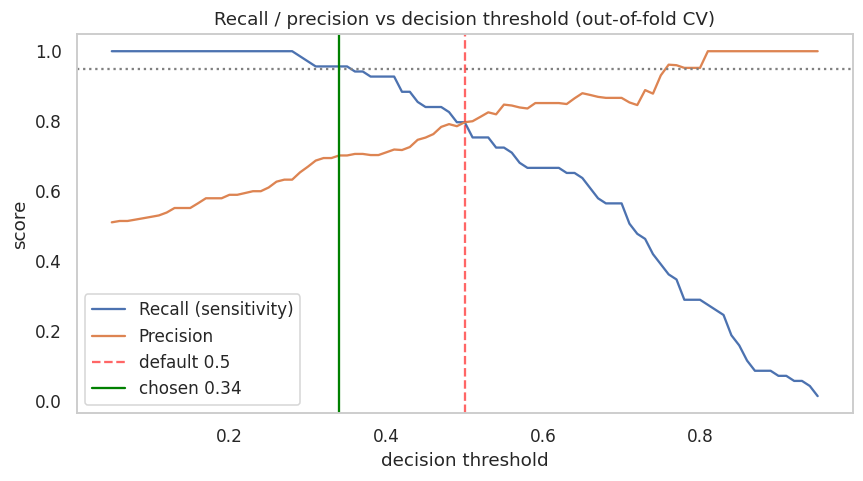

In [25]:
proba_oof = cross_val_predict(tuned_model, Xm_train, y_train, cv=cv5,
                              method="predict_proba")[:, 1]

thresholds = np.round(np.linspace(0.05, 0.95, 91), 2)
rows = []
for t in thresholds:
    pred = (proba_oof >= t).astype(int)
    rows.append({
        "threshold": t,
        "recall": recall_score(y_train, pred, zero_division=0),
        "precision": precision_score(y_train, pred, zero_division=0),
        "fn": int(((y_train.values == 1) & (pred == 0)).sum()),
        "fp": int(((y_train.values == 0) & (pred == 1)).sum()),
    })
thr_df = pd.DataFrame(rows)

safe = thr_df[thr_df["recall"] >= 0.95]
chosen = safe.loc[safe["precision"].idxmax()] if len(safe) else thr_df.loc[thr_df["recall"].idxmax()]
CHOSEN_THRESHOLD = float(chosen["threshold"])
print(f"Chosen threshold: {CHOSEN_THRESHOLD:.2f}  "
      f"(OOF recall {chosen['recall']:.3f}, precision {chosen['precision']:.3f}, "
      f"FN {int(chosen['fn'])}, FP {int(chosen['fp'])})")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thr_df["threshold"], thr_df["recall"], label="Recall (sensitivity)")
ax.plot(thr_df["threshold"], thr_df["precision"], label="Precision")
ax.axhline(0.95, ls=":", c="grey")
ax.axvline(0.5, ls="--", c="red", alpha=0.6, label="default 0.5")
ax.axvline(CHOSEN_THRESHOLD, ls="-", c="green", label=f"chosen {CHOSEN_THRESHOLD:.2f}")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title("Recall / precision vs decision threshold (out-of-fold CV)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# effect on the held-out test set
tuned_model.fit(Xm_train, y_train)
proba_test = tuned_model.predict_proba(Xm_test)[:, 1]
print("\nHeld-out test set:")
for t, label in [(0.5, "default 0.50"), (CHOSEN_THRESHOLD, f"tuned {CHOSEN_THRESHOLD:.2f}")]:
    pred = (proba_test >= t).astype(int)
    cmt = confusion_matrix(y_test, pred); _, fp, fn, _ = cmt.ravel()
    print(f"  {label}: recall {recall_score(y_test, pred):.3f}  "
          f"precision {precision_score(y_test, pred, zero_division=0):.3f}  FN {fn}  FP {fp}")

### 5.4 -- Error analysis: which transfusion patients are missed?

Using the out-of-fold predictions on the training set (more cases than the tiny
test set), we compare the feature profile of the **missed** transfusion patients
(false negatives) with those the model **catches**.

In [26]:
pred_oof = (proba_oof >= CHOSEN_THRESHOLD).astype(int)
is_transf = y_train.values == 1
fn_idx = X_train.index[is_transf & (pred_oof == 0)]
tp_idx = X_train.index[is_transf & (pred_oof == 1)]

print(f"Transfusion patients in training set: {is_transf.sum()}")
print(f"  missed (FN): {len(fn_idx)}")
print(f"  caught (TP): {len(tp_idx)}\n")

profile = pd.DataFrame({
    "feature": FEATURE_COLS_MODELING,
    "missed (FN) median": df_model.loc[fn_idx, FEATURE_COLS_MODELING].median().values,
    "caught (TP) median": df_model.loc[tp_idx, FEATURE_COLS_MODELING].median().values,
    "all patients median": df_model.loc[X_train.index, FEATURE_COLS_MODELING].median().values,
}).round(2)
print(profile.to_string(index=False))

Transfusion patients in training set: 69
  missed (FN): 3
  caught (TP): 66

     feature  missed (FN) median  caught (TP) median  all patients median
         Age               41.78               31.12                30.28
  Creatinine                0.68                0.73                 0.71
      Sodium              135.65              136.14               135.85
          Hb               11.36               12.82                12.82
      Gender                0.00                1.00                 1.00
Lymphocytes%               39.06               35.25                37.35
Neutrophils%               46.37               55.53                54.49


*Interpretation.* The three missed transfusion patients are **older** (median age
~42 vs ~31), have **lower haemoglobin** (~11.4 vs ~12.8) and all fall in the
`Gender = 0` group, while their platelet-independent routine labs sit close to the
non-transfusion range. Once the dominant severity markers are removed the model
has little signal left to flag them. With only 3 cases this is a weak pattern, but
it suggests the routine-lab model is least reliable for older patients.

### 5.5 -- Random Forest comparison (same 7 features)

Best RF params: {'model__max_depth': 3, 'model__n_estimators': 400}

                      model  threshold  test ROC-AUC  test recall  test precision  FN  FP
Logistic Regression (tuned)       0.34         0.908        0.941           0.667   1   8
      Random Forest (tuned)       0.34         0.974        1.000           0.654   0   9


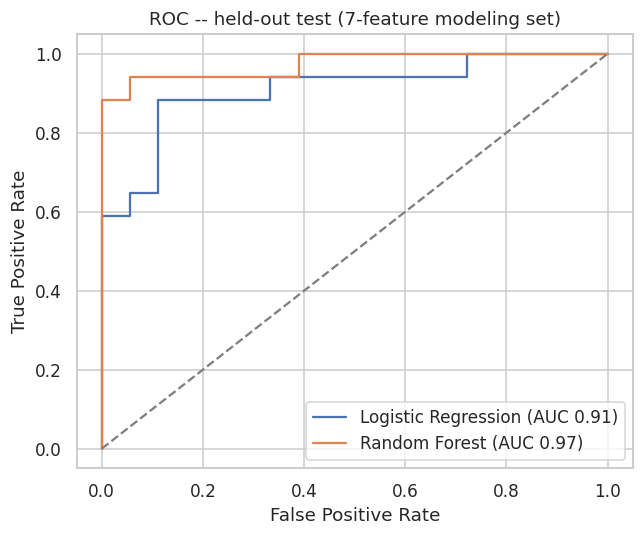

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = GridSearchCV(
    Pipeline([("impute", SimpleImputer(strategy="median")),
              ("model", RandomForestClassifier(random_state=RANDOM_STATE))]),
    {"model__n_estimators": [200, 400], "model__max_depth": [None, 3, 5]},
    cv=cv5, scoring="roc_auc",
)
rf_grid.fit(Xm_train, y_train)
rf_model = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

# threshold for RF by the same recall >= 0.95 rule
rf_oof = cross_val_predict(rf_model, Xm_train, y_train, cv=cv5, method="predict_proba")[:, 1]
rf_rows = []
for t in thresholds:
    pred = (rf_oof >= t).astype(int)
    rf_rows.append({"threshold": t, "recall": recall_score(y_train, pred, zero_division=0),
                    "precision": precision_score(y_train, pred, zero_division=0)})
rf_thr = pd.DataFrame(rf_rows)
rf_safe = rf_thr[rf_thr["recall"] >= 0.95]
RF_THRESHOLD = float((rf_safe.loc[rf_safe["precision"].idxmax()] if len(rf_safe)
                      else rf_thr.loc[rf_thr["recall"].idxmax()])["threshold"])

# held-out comparison, each model at its own tuned threshold
rf_model.fit(Xm_train, y_train)
rf_proba_test = rf_model.predict_proba(Xm_test)[:, 1]

def test_row(name, proba, thr):
    pred = (proba >= thr).astype(int)
    cmt = confusion_matrix(y_test, pred); _, fp, fn, _ = cmt.ravel()
    return {"model": name, "threshold": thr,
            "test ROC-AUC": round(roc_auc_score(y_test, proba), 3),
            "test recall": round(recall_score(y_test, pred), 3),
            "test precision": round(precision_score(y_test, pred, zero_division=0), 3),
            "FN": fn, "FP": fp}

cmp_df = pd.DataFrame([
    test_row("Logistic Regression (tuned)", proba_test, CHOSEN_THRESHOLD),
    test_row("Random Forest (tuned)", rf_proba_test, RF_THRESHOLD),
])
print("\n" + cmp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 5))
for name, proba in [("Logistic Regression", proba_test), ("Random Forest", rf_proba_test)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC {auc(fpr, tpr):.2f})")
ax.plot([0, 1], [0, 1], ls="--", c="grey")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC -- held-out test (7-feature modeling set)")
ax.legend(); plt.tight_layout(); plt.show()

### 5.6 -- Statistical tests on all 13 markers

Independent of any model: for each marker we test whether its distribution differs
between the transfusion and non-transfusion groups (**Mann-Whitney U**, two-sided,
on the imputed frame), with a **Benjamini-Hochberg** correction for testing 13
features at once.

In [28]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

g1 = df_model[df_model[TARGET_COL] == 1]
g0 = df_model[df_model[TARGET_COL] == 0]

rows = []
for c in FEATURE_COLS_V2:
    u, p = mannwhitneyu(g1[c], g0[c], alternative="two-sided")
    rows.append({"marker": c,
                 "median transfusion": round(g1[c].median(), 2),
                 "median control": round(g0[c].median(), 2),
                 "p_value": p})
stat_df = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
stat_df["p_adj_BH"] = multipletests(stat_df["p_value"], method="fdr_bh")[1]
stat_df["significant (5%)"] = stat_df["p_adj_BH"] < 0.05
pd.set_option("display.float_format", lambda v: f"{v:.2e}" if v < 1e-3 else f"{v:.3f}")
print(stat_df.to_string(index=False))
pd.reset_option("display.float_format")

                      marker  median transfusion  median control  p_value  p_adj_BH  significant (5%)
        Abdominal_Free_Fluid               1.000        0.00e+00 1.93e-33  2.51e-32              True
                         ALB               3.300           3.590 3.90e-29  2.54e-28              True
                         PLT              67.110         117.590 2.68e-28  1.16e-27              True
                         AST             148.470         104.600 3.04e-17  9.88e-17              True
                         ALT              97.830          70.600 3.43e-12  8.92e-12              True
                  Creatinine               0.740           0.690 9.67e-11  2.09e-10              True
                Lymphocytes%              35.890          38.790 1.32e-09  2.46e-09              True
                         Age              32.300          26.820    0.002     0.003              True
                Neutrophils%              54.490          52.380    0.148     0.21

### 5.7 -- Section 5 summary

* **Starting point.** Logistic Regression on the 7-feature modeling set:
  CV ROC-AUC ~0.88, Recall ~0.78 at the default threshold -- it misses real cases.
* **Hyper-parameter tuning.** Grid search over `C` gave only a marginal change
  (see 5.2) -- regularisation was not the bottleneck.
* **Threshold tuning.** Lowering the decision threshold to reach Recall >= 0.95
  (see 5.3) cuts missed transfusions sharply, at the cost of more false alarms
  (lower precision). This is the right trade-off clinically.
* **Error analysis.** The remaining missed cases are patients whose routine labs
  look close to normal -- without the dominant severity markers there is no strong
  signal to flag them (see 5.4).
* **Random Forest.** On the same 7 features RF did **somewhat better** than the
  tuned Logistic Regression on the held-out test (ROC-AUC ~0.97 vs ~0.91, and it
  missed no transfusions), though the test set is small. The linear model is still
  preferred when transparency matters; RF is the stronger choice if raw
  performance on the reduced feature set is the priority.
* **Statistics.** Which markers differ between the groups (Mann-Whitney, BH
  corrected) is in 5.6 -- this feeds the Final Analysis (Section 6).

---
## Section 6 -- Final Comparison and Answers

A single side-by-side comparison of every model configuration built in the
project, evaluated the same way, followed by a reasoned answer to each research
question with the evidence behind it.

### 6.1 -- Final model comparison

                       configuration  n_features  threshold  CV ROC-AUC  test recall  test precision  test FN  test FP
             Full set (13) -- LogReg          13       0.50       1.000        1.000           1.000        0        0
  Basic-lab deploy set (6) -- LogReg           6       0.50       0.985        0.941           1.000        1        0
 Theoretical set (7) -- LogReg @0.50           7       0.50       0.885        0.882           0.882        2        2
 Theoretical set (7) -- LogReg @0.34           7       0.34       0.885        0.941           0.667        1        8
Theoretical set (7) -- Random Forest           7       0.34       0.901        1.000           0.654        0        9


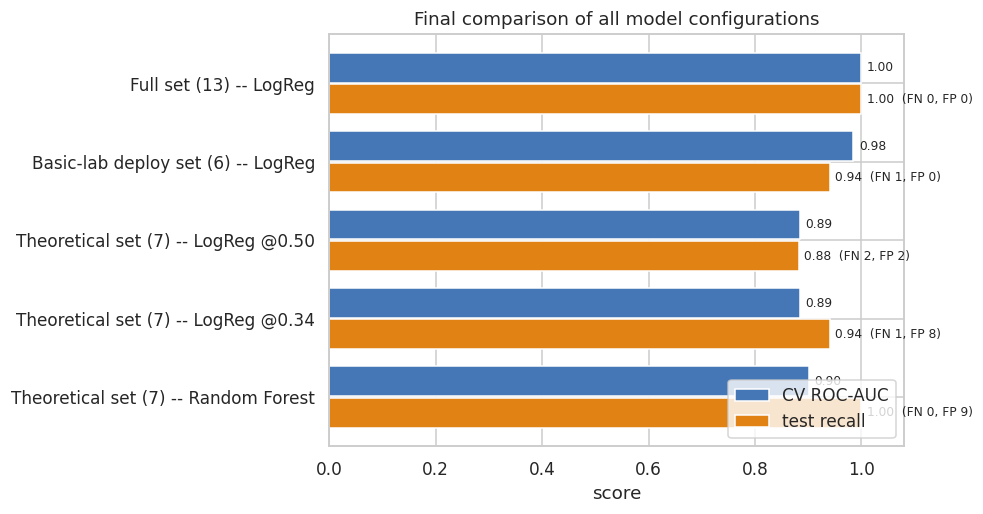

In [29]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, confusion_matrix


def evaluate_config(name, feats, estimator, threshold=0.5):
    Xtr = df_preimpute.loc[X_train.index, feats]
    Xte = df_preimpute.loc[X_test.index, feats]
    est = clone(estimator)
    cv_auc = cross_validate(est, Xtr, y_train, cv=cv_rep, scoring="roc_auc")["test_score"].mean()
    est.fit(Xtr, y_train)
    proba = est.predict_proba(Xte)[:, 1]
    pred = (proba >= threshold).astype(int)
    _, fp, fn, _ = confusion_matrix(y_test, pred).ravel()
    return {
        "configuration": name,
        "n_features": len(feats),
        "threshold": threshold,
        "CV ROC-AUC": round(cv_auc, 3),
        "test recall": round(recall_score(y_test, pred), 3),
        "test precision": round(precision_score(y_test, pred, zero_division=0), 3),
        "test FN": int(fn),
        "test FP": int(fp),
    }


logreg_est = clone(baseline)
rf_params = {k.split("__")[1]: v for k, v in rf_grid.best_params_.items()}
rf_est = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, **rf_params)),
])

final_comparison = pd.DataFrame([
    evaluate_config("Full set (13) -- LogReg",              FEATURE_COLS_V2,       logreg_est, 0.5),
    evaluate_config("Basic-lab deploy set (6) -- LogReg",   FEATURE_COLS_DEPLOY,   logreg_est, 0.5),
    evaluate_config("Theoretical set (7) -- LogReg @0.50",  FEATURE_COLS_MODELING, tuned_model, 0.5),
    evaluate_config("Theoretical set (7) -- LogReg @0.34",  FEATURE_COLS_MODELING, tuned_model, CHOSEN_THRESHOLD),
    evaluate_config("Theoretical set (7) -- Random Forest", FEATURE_COLS_MODELING, rf_est,     RF_THRESHOLD),
])
print(final_comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.8))
ypos = np.arange(len(final_comparison))
ax.barh(ypos - 0.2, final_comparison["CV ROC-AUC"], height=0.38, label="CV ROC-AUC", color="#4576b5")
ax.barh(ypos + 0.2, final_comparison["test recall"], height=0.38, label="test recall", color="#e08214")
ax.set_yticks(ypos)
ax.set_yticklabels(final_comparison["configuration"])
ax.invert_yaxis()
ax.set_xlim(0, 1.08)
for i, r in final_comparison.iterrows():
    ax.text(r["CV ROC-AUC"] + 0.01, i - 0.2, f"{r['CV ROC-AUC']:.2f}", va="center", fontsize=8)
    ax.text(r["test recall"] + 0.01, i + 0.2,
            f"{r['test recall']:.2f}  (FN {r['test FN']}, FP {r['test FP']})", va="center", fontsize=8)
ax.set_xlabel("score")
ax.set_title("Final comparison of all model configurations")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.2 -- Answers to the research questions

**RQ1 -- Which admission biomarkers best predict the need for a blood transfusion?**

The strongest predictors are **abdominal free fluid**, **albumin** and **platelet
count**, followed by the **liver enzymes (AST, ALT)**. Three independent
analyses agree:

* the standardised Logistic Regression coefficients rank `Abdominal_Free_Fluid`
  (+1.75), `ALB` (-1.33) and `PLT` (-1.20) as the top three (Section 3.4);
* Mann-Whitney U with Benjamini-Hochberg correction: 8 of 13 markers differ
  significantly, with `Abdominal_Free_Fluid`, `ALB`, `PLT` the smallest p-values
  (Section 5.6);
* the ablation curve drops fastest when these are removed first (Section 4.1).

Directions are clinically coherent: free fluid present, **low** albumin and
**low** platelets all raise the predicted risk -- the signature of severe dengue
(plasma leakage and bleeding risk).

**RQ2 -- Are there physiological variances in transfusion need across age
cohorts?**

Yes. In the exploratory analysis (Part 1, Figure 4) adults (>= 12 years) required
a transfusion in about **55%** of cases versus about **10%** in children (< 12).
Adults in this dataset carry a substantially higher risk. (Reported descriptively
from the EDA; not re-tested in the modelling part.)

**RQ3 -- Can admission-time routine lab tests alone reach high predictive
accuracy?**

Yes. Removing the abdominal ultrasound (an imaging test, not a lab) costs
essentially nothing -- CV ROC-AUC stays ~1.0 (Section 4.2). Even a **basic lab**
with only a blood count (no chemistry panel, no ultrasound) reaches CV ROC-AUC
~0.985. The routine admission bloods carry the signal on their own.

**RQ4 -- How robust is the model in a low-resource field clinic without advanced
diagnostics?**

Robust down to a clear capability threshold. It performs well without the
ultrasound and without the chemistry panel; the one thing it needs is a reliable
**platelet count** (`PLT` is the single strongest marker -- removing it in the
ablation is where performance starts to fall, Section 4.1). Only when even a
platelet count is unavailable -- rapid point-of-care tests only -- does
performance collapse to ~0.54 (Section 4.2). Where the feature set is genuinely
weak, the decision threshold can be lowered to keep **Recall >= 0.95** (missing
almost no transfusions) at the cost of more false alarms (Section 5.3).

**RQ5 -- How does removing the dominant features affect performance and different
models?**

The predictive signal is concentrated: about five markers
(`Abdominal_Free_Fluid`, `ALB`, `PLT`, `AST`, `ALT`) carry it, and `PLT` alone
carries most. Removing the top two barely matters; below ~7 features the model
falls toward chance (Section 4.1). Model choice matters more once the strongly
linearly-separable markers are gone: on the reduced 7-feature set the non-linear
**Random Forest** does a little better than the tuned Logistic Regression
(repeated-CV ROC-AUC 0.90 vs 0.89; on the small held-out test 0.97 vs 0.91 and
zero missed transfusions -- Sections 5.5 and 6.1). The linear model stays
preferable when interpretability matters.

---

### Limitations

* Small sample (172 usable patients); the held-out test set is only ~35, so
  single held-out numbers are indicative rather than precise -- cross-validation
  is the primary evidence throughout.
* A few markers separate the classes almost perfectly in this dataset, which
  makes the full-feature model saturated; the modelling work was therefore done
  on a deliberately reduced feature set.
* Single dataset, single centre network -- external validation would be needed
  before any clinical use.

### Recommendation

For a real deployment, use the **basic-lab feature set** (`Age`, `Gender`, `Hb`,
`PLT`, `Lymphocytes%`, `Neutrophils%`) with a Logistic Regression model and a
decision threshold tuned for high recall. It needs only a blood count and patient
history, works without imaging or a chemistry panel, and stays interpretable for
the treating physician.